# 🚗 DoorDash Delivery Prediction
## Notebook 04b — Feature Refinement & Improved Modeling

**Goal:** Add interaction terms based on feature importance insights from notebook 04. Compare improved model against baseline.

**Baseline reference:** `04_modeling.ipynb`

**Why interaction terms?**
> A single feature like `order_hour` tells us *when* the order was placed.
> But `order_hour × estimated_store_to_consumer_driving_duration` tells us
> *how bad peak hour gets when the delivery is also far away* — a much richer signal.

**Author:** Divyargarg

---

In [22]:
# ── CELL 1: Import Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [23]:
# ── CELL 2: Load Feature Data ─────────────────────────────────────────
df = pd.read_csv('../data/features/features_data.csv')

print(f'✅ Feature data loaded!')
print(f'📊 Shape: {df.shape}')
print(f'\n📋 Columns:')
for col in df.columns:
    print(f'  → {col}')

✅ Feature data loaded!
📊 Shape: (197283, 16)

📋 Columns:
  → store_primary_category
  → order_protocol
  → total_items
  → subtotal
  → min_item_price
  → max_item_price
  → total_onshift_dashers
  → estimated_order_place_duration
  → estimated_store_to_consumer_driving_duration
  → total_delivery_duration_mins
  → order_hour
  → order_day_of_week
  → order_month
  → is_weekend
  → is_rush_hour
  → is_late_night


In [25]:
# ── CELL 3: Load Baseline Results from Notebook 04 ────────────────────
# Hardcode your baseline scores here from notebook 04 output
# We'll use these to compare against the improved model later

baseline_results = {
    'Linear Regression': {'MAE': 12.468, 'RMSE': 16.739, 'R2': 0.1413},
    'Random Forest'    : {'MAE': 11.876, 'RMSE': 15.905, 'R2': 0.2247},
    'XGBoost'          : {'MAE': 11.348, 'RMSE': 15.383, 'R2': 0.2748},
}

# ⚠️ Fill in YOUR actual scores from notebook 04 Cell 11
# Example:
# baseline_results['XGBoost'] = {'MAE': 8.23, 'RMSE': 11.45, 'R2': 0.72}

print('📊 Baseline scores loaded (fill in from notebook 04):')
for model, scores in baseline_results.items():
    print(f'  {model}: {scores}')

📊 Baseline scores loaded (fill in from notebook 04):
  Linear Regression: {'MAE': 12.468, 'RMSE': 16.739, 'R2': 0.1413}
  Random Forest: {'MAE': 11.876, 'RMSE': 15.905, 'R2': 0.2247}
  XGBoost: {'MAE': 11.348, 'RMSE': 15.383, 'R2': 0.2748}


## 🔗 Step 1 — Add Interaction Terms

Based on feature importance chart, our top features are:
1. `order_hour` (0.18) 
2. `order_month` (0.16)
3. `estimated_order_place_duration` (0.105)
4. `order_day_of_week` (0.102)
5. `estimated_store_to_consumer_driving_duration` (0.100)

We'll create interactions between these to capture compound effects.

In [26]:
# ── CELL 4: Interaction Term 1 ────────────────────────────────────────
# order_hour × order_day_of_week
# WHY: Monday 8pm rush behaves differently than Friday 8pm rush
# A Friday evening order at hour 19 could be 2x slower than a Tuesday

df['hour_x_day'] = df['order_hour'] * df['order_day_of_week']

# Quick check — correlation with target
TARGET = 'total_delivery_duration_mins'
corr = df['hour_x_day'].corr(df[TARGET])
print(f'✅ hour_x_day created')
print(f'   Correlation with target: {corr:.4f}')
print(f'   Sample values: {df["hour_x_day"].describe().round(2).to_dict()}')

✅ hour_x_day created
   Correlation with target: -0.1383
   Sample values: {'count': 197283.0, 'mean': 27.59, 'std': 37.48, 'min': 0.0, '25%': 3.0, '50%': 10.0, '75%': 38.0, 'max': 138.0}


In [27]:
# ── CELL 5: Interaction Term 2 ────────────────────────────────────────
# order_hour × estimated_store_to_consumer_driving_duration
# WHY: A long delivery during peak hour is the worst case scenario
# This captures the compounding effect of both factors together

if 'estimated_store_to_consumer_driving_duration' in df.columns:
    df['hour_x_drive_duration'] = (
        df['order_hour'] * df['estimated_store_to_consumer_driving_duration']
    )
    corr = df['hour_x_drive_duration'].corr(df[TARGET])
    print(f'✅ hour_x_drive_duration created')
    print(f'   Correlation with target: {corr:.4f}')
else:
    print('⚠️  estimated_store_to_consumer_driving_duration not found — skipping')

✅ hour_x_drive_duration created
   Correlation with target: -0.0698


In [28]:
# ── CELL 6: Interaction Term 3 ────────────────────────────────────────
# order_hour × estimated_order_place_duration
# WHY: A slow restaurant during rush hour compounds the delay
# If a restaurant is already slow AND it's peak time → much longer wait

if 'estimated_order_place_duration' in df.columns:
    df['hour_x_order_place'] = (
        df['order_hour'] * df['estimated_order_place_duration']
    )
    corr = df['hour_x_order_place'].corr(df[TARGET])
    print(f'✅ hour_x_order_place created')
    print(f'   Correlation with target: {corr:.4f}')
else:
    print('⚠️  estimated_order_place_duration not found — skipping')

✅ hour_x_order_place created
   Correlation with target: -0.1366


In [29]:
# ── CELL 7: Interaction Term 4 ────────────────────────────────────────
# order_month × order_day_of_week
# WHY: December Fridays are very different from July Fridays
# Seasonal patterns interact with day-of-week patterns

df['month_x_day'] = df['order_month'] * df['order_day_of_week']

corr = df['month_x_day'].corr(df[TARGET])
print(f'✅ month_x_day created')
print(f'   Correlation with target: {corr:.4f}')

✅ month_x_day created
   Correlation with target: 0.0087


In [30]:
# ── CELL 8: Interaction Term 5 ────────────────────────────────────────
# subtotal × total_items
# WHY: High value + many items = complex order that takes longer to prepare
# A $80 order with 10 items is very different from a $80 order with 2 items

if 'subtotal' in df.columns and 'total_items' in df.columns:
    df['subtotal_x_items'] = df['subtotal'] * df['total_items']
    corr = df['subtotal_x_items'].corr(df[TARGET])
    print(f'✅ subtotal_x_items created')
    print(f'   Correlation with target: {corr:.4f}')
elif 'subtotal' in df.columns and 'num_items' in df.columns:
    df['subtotal_x_items'] = df['subtotal'] * df['num_items']
    corr = df['subtotal_x_items'].corr(df[TARGET])
    print(f'✅ subtotal_x_items created (using num_items)')
    print(f'   Correlation with target: {corr:.4f}')
else:
    print('⚠️  subtotal or items column not found — skipping')

✅ subtotal_x_items created
   Correlation with target: 0.1933


In [31]:
# ── CELL 9: Interaction Term 6 ────────────────────────────────────────
# is_rush_hour × estimated_order_place_duration
# WHY: Rush hour flag × restaurant speed = captures worst case
# Binary × continuous gives the model a clean "rush hour penalty" signal

if 'is_rush_hour' in df.columns and 'estimated_order_place_duration' in df.columns:
    df['rush_x_order_place'] = (
        df['is_rush_hour'] * df['estimated_order_place_duration']
    )
    corr = df['rush_x_order_place'].corr(df[TARGET])
    print(f'✅ rush_x_order_place created')
    print(f'   Correlation with target: {corr:.4f}')
else:
    print('⚠️  is_rush_hour or estimated_order_place_duration not found — skipping')

✅ rush_x_order_place created
   Correlation with target: -0.0709


In [32]:
# ── CELL 10: Interaction Term 7 ───────────────────────────────────────
# total_onshift_dashers × estimated_store_to_consumer_driving_duration
# WHY: More dashers available for long routes means faster assignment
# Low dashers + long route = biggest delay risk

if 'total_onshift_dashers' in df.columns and 'estimated_store_to_consumer_driving_duration' in df.columns:
    df['dashers_x_drive'] = (
        df['total_onshift_dashers'] * df['estimated_store_to_consumer_driving_duration']
    )
    corr = df['dashers_x_drive'].corr(df[TARGET])
    print(f'✅ dashers_x_drive created')
    print(f'   Correlation with target: {corr:.4f}')
else:
    print('⚠️  total_onshift_dashers or drive_duration not found — skipping')

✅ dashers_x_drive created
   Correlation with target: 0.1572


In [33]:
# ── CELL 11: Polynomial Feature — order_hour² ─────────────────────────
# WHY: The relationship between hour and delivery time is NOT linear
# Deliveries at 12pm and 7pm are both slow — but midnight is fast again
# A squared term lets the model learn this U-shaped / curved relationship

df['order_hour_squared'] = df['order_hour'] ** 2

corr = df['order_hour_squared'].corr(df[TARGET])
print(f'✅ order_hour_squared created')
print(f'   Correlation with target: {corr:.4f}')
print(f'   (Compare to order_hour correlation: {df["order_hour"].corr(df[TARGET]):.4f})')

✅ order_hour_squared created
   Correlation with target: -0.1706
   (Compare to order_hour correlation: -0.1714)


In [34]:
# ── CELL 12: Ratio Feature — dashers per order ────────────────────────
# WHY: Raw dasher count is less meaningful than dashers relative to demand
# 10 dashers with 100 orders = very different from 10 dashers with 5 orders

if 'total_onshift_dashers' in df.columns and 'total_busy_dashers' in df.columns:
    # Ratio of busy dashers to total — higher = more constrained supply
    df['dasher_busy_ratio'] = (
        df['total_busy_dashers'] / (df['total_onshift_dashers'] + 1)  # +1 avoids divide by zero
    )
    corr = df['dasher_busy_ratio'].corr(df[TARGET])
    print(f'✅ dasher_busy_ratio created (busy / total dashers)')
    print(f'   Correlation with target: {corr:.4f}')
    print(f'   Range: {df["dasher_busy_ratio"].min():.2f} → {df["dasher_busy_ratio"].max():.2f}')
else:
    print('⚠️  total_onshift_dashers or total_busy_dashers not found — skipping')

⚠️  total_onshift_dashers or total_busy_dashers not found — skipping


In [35]:
# ── CELL 13: Summary of All New Features ─────────────────────────────
original_cols = pd.read_csv('../data/features/features_data.csv').columns.tolist()
new_features  = [col for col in df.columns if col not in original_cols]

print(f'📊 New features added: {len(new_features)}')
print(f'📊 Total features now: {len(df.columns) - 1} (excl. target)\n')

# Show correlation of each new feature with target
print(f'{"Feature":<35} {"Correlation with target"}')
print('-' * 60)
for col in new_features:
    corr = df[col].corr(df[TARGET])
    bar = '█' * int(abs(corr) * 40)
    direction = '+' if corr > 0 else '-'
    print(f'{col:<35} {direction}{abs(corr):.4f}  {bar}')

📊 New features added: 8
📊 Total features now: 23 (excl. target)

Feature                             Correlation with target
------------------------------------------------------------
hour_x_day                          -0.1383  █████
hour_x_drive_duration               -0.0698  ██
hour_x_order_place                  -0.1366  █████
month_x_day                         +0.0087  
subtotal_x_items                    +0.1933  ███████
rush_x_order_place                  -0.0709  ██
dashers_x_drive                     +0.1572  ██████
order_hour_squared                  -0.1706  ██████


## 🤖 Step 2 — Re-Train Models with New Features

In [36]:
# ── CELL 14: Encode & Split ───────────────────────────────────────────
TARGET = 'total_delivery_duration_mins'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if X[col].nunique() <= 10:
        dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
        X = pd.concat([X.drop(columns=[col]), dummies], axis=1)
    else:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'📊 Total features going into models: {X_train.shape[1]}')

✅ Train: 138098 | Val: 29592 | Test: 29593
📊 Total features going into models: 23


In [37]:
# ── CELL 15: Helper Function ──────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    return {
        'Model'     : name,
        'MAE (mins)': round(mean_absolute_error(y_v, y_pred), 3),
        'RMSE (mins)': round(np.sqrt(mean_squared_error(y_v, y_pred)), 3),
        'R²'        : round(r2_score(y_v, y_pred), 4)
    }, model

print('✅ evaluate_model() ready!')

✅ evaluate_model() ready!


In [38]:
# ── CELL 16: Train All 3 Models ───────────────────────────────────────
lr_res,  lr_model  = evaluate_model('Linear Regression', LinearRegression(),
                                     X_train_scaled, y_train, X_val_scaled, y_val)

rf_res,  rf_model  = evaluate_model('Random Forest',
                                     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                                     X_train, y_train, X_val, y_val)

xgb_res, xgb_model = evaluate_model('XGBoost',
                                     XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
                                     X_train, y_train, X_val, y_val)

improved_results = pd.DataFrame([lr_res, rf_res, xgb_res]).set_index('Model')
print('📊 IMPROVED MODEL RESULTS (Validation Set):')
print(improved_results.to_string())

📊 IMPROVED MODEL RESULTS (Validation Set):
                   MAE (mins)  RMSE (mins)      R²
Model                                             
Linear Regression      12.402       16.657  0.1497
Random Forest          11.839       15.874  0.2277
XGBoost                11.358       15.408  0.2724


## 📊 Step 3 — Baseline vs Improved Comparison

📊 BASELINE vs IMPROVED:
                   Baseline MAE  Improved MAE  Baseline R²  Improved R²
Model                                                                  
Linear Regression        12.468        12.402       0.1413       0.1497
Random Forest            11.876        11.839       0.2247       0.2277
XGBoost                  11.348        11.358       0.2748       0.2724


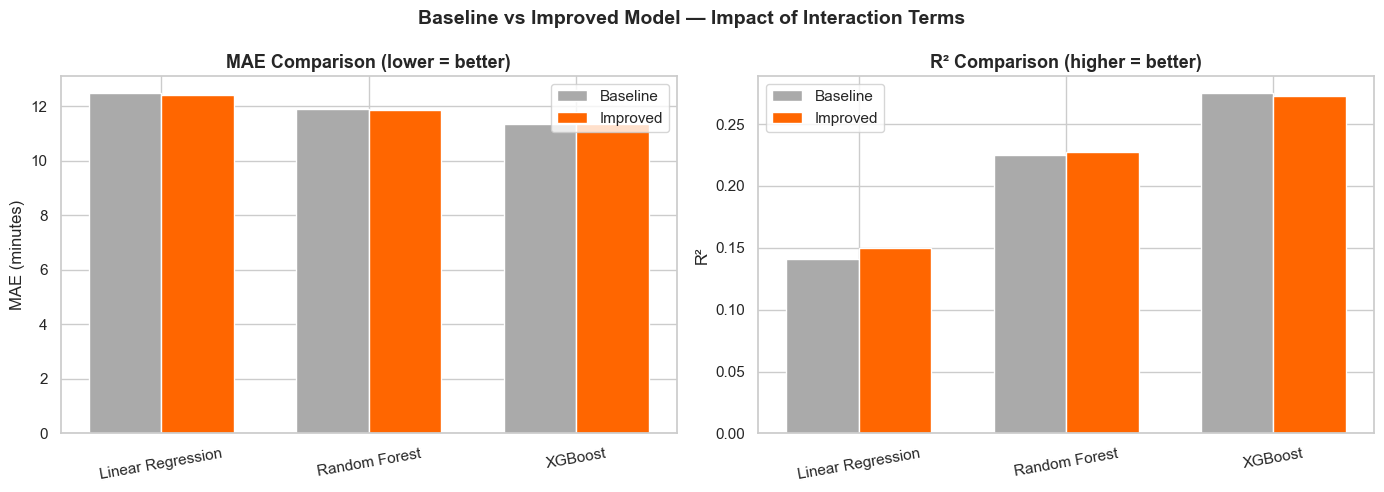

✅ Saved to outputs/figures/


In [39]:
# ── CELL 17: Side-by-Side Comparison Chart ────────────────────────────
# Fill baseline_results in Cell 3 first for this to work properly

# Build comparison dataframe
comparison_data = []
for model_name in ['Linear Regression', 'Random Forest', 'XGBoost']:
    improved_row = improved_results.loc[model_name]
    baseline     = baseline_results[model_name]

    comparison_data.append({
        'Model'           : model_name,
        'Baseline MAE'    : baseline['MAE'],
        'Improved MAE'    : improved_row['MAE (mins)'],
        'Baseline R²'     : baseline['R2'],
        'Improved R²'     : improved_row['R²'],
    })

comp_df = pd.DataFrame(comparison_data).set_index('Model')
print('📊 BASELINE vs IMPROVED:')
print(comp_df.to_string())

# Plot MAE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comp_df.index.tolist()
x = np.arange(len(models))
width = 0.35

# MAE chart (lower is better)
axes[0].bar(x - width/2, comp_df['Baseline MAE'], width, label='Baseline',
            color='#AAAAAA', edgecolor='white')
axes[0].bar(x + width/2, comp_df['Improved MAE'], width, label='Improved',
            color='#FF6600', edgecolor='white')
axes[0].set_title('MAE Comparison (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MAE (minutes)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10)
axes[0].legend()

# R² chart (higher is better)
axes[1].bar(x - width/2, comp_df['Baseline R²'], width, label='Baseline',
            color='#AAAAAA', edgecolor='white')
axes[1].bar(x + width/2, comp_df['Improved R²'], width, label='Improved',
            color='#FF6600', edgecolor='white')
axes[1].set_title('R² Comparison (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=10)
axes[1].legend()

plt.suptitle('Baseline vs Improved Model — Impact of Interaction Terms',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04b_baseline_vs_improved.png', dpi=150)
plt.show()
print('✅ Saved to outputs/figures/')

In [40]:
# ── CELL 18: Improvement Summary Table ───────────────────────────────
print('📊 IMPROVEMENT SUMMARY:')
print(f'{"Model":<22} {"MAE Change":<18} {"R² Change":<15} {"Verdict"}')
print('-' * 70)

for model_name in ['Linear Regression', 'Random Forest', 'XGBoost']:
    b = baseline_results[model_name]
    i = improved_results.loc[model_name]

    if b['MAE'] and b['R2']:   # only if baseline was filled in
        mae_delta = i['MAE (mins)'] - b['MAE']
        r2_delta  = i['R²'] - b['R2']
        mae_str   = f'{mae_delta:+.3f} mins'
        r2_str    = f'{r2_delta:+.4f}'
        verdict   = '✅ Better' if mae_delta < 0 else '❌ Worse' if mae_delta > 0.5 else '➡️  Similar'
        print(f'{model_name:<22} {mae_str:<18} {r2_str:<15} {verdict}')
    else:
        print(f'{model_name:<22} Fill baseline scores in Cell 3 to see comparison')

📊 IMPROVEMENT SUMMARY:
Model                  MAE Change         R² Change       Verdict
----------------------------------------------------------------------
Linear Regression      -0.066 mins        +0.0084         ✅ Better
Random Forest          -0.037 mins        +0.0030         ✅ Better
XGBoost                +0.010 mins        -0.0024         ➡️  Similar


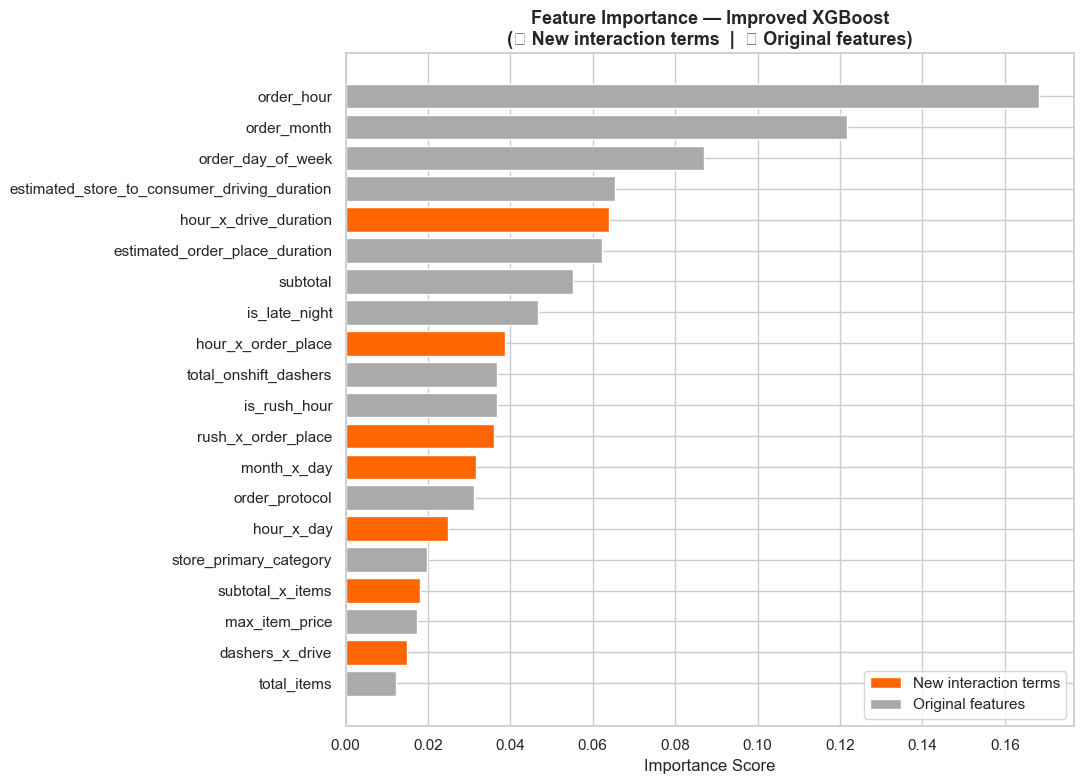

✅ Saved!


In [41]:
# ── CELL 19: Feature Importance — New vs Old Features ─────────────────
# See if interaction terms rank highly in the improved model

original_cols = pd.read_csv('../data/features/features_data.csv').columns.tolist()
original_cols = [c for c in original_cols if c != TARGET]
new_features  = [col for col in X.columns if col not in original_cols]

importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': xgb_model.feature_importances_,
    'is_new'    : ['New ✨' if col in new_features else 'Original' for col in X.columns]
}).sort_values('importance', ascending=True).tail(20)

colors = ['#FF6600' if t == 'New ✨' else '#AAAAAA' for t in importance_df['is_new']]

plt.figure(figsize=(11, 8))
plt.barh(importance_df['feature'], importance_df['importance'],
         color=colors, edgecolor='white')
plt.title('Feature Importance — Improved XGBoost\n(🟠 New interaction terms  |  ⬜ Original features)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6600', label='New interaction terms'),
                   Patch(facecolor='#AAAAAA', label='Original features')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/figures/04b_feature_importance_improved.png', dpi=150)
plt.show()
print('✅ Saved!')

In [42]:
# ── CELL 20: Save Best Improved Model ────────────────────────────────
# Save features v2
df.to_csv('../data/features/features_v2.csv', index=False)

# Save improved model
with open('../outputs/models/best_model_v2.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save test predictions from improved model
y_pred_test = xgb_model.predict(X_test)
test_results = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred_test})
test_results.to_csv('../outputs/models/test_predictions_v2.csv', index=False)

print('✅ features_v2.csv         → data/features/')
print('✅ best_model_v2.pkl       → outputs/models/')
print('✅ test_predictions_v2.csv → outputs/models/')

# Final test set metrics
mae  = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test, y_pred_test)
print(f'\n📊 FINAL TEST SET — Improved XGBoost:')
print(f'  MAE  : {mae:.2f} mins')
print(f'  RMSE : {rmse:.2f} mins')
print(f'  R²   : {r2:.4f}')

✅ features_v2.csv         → data/features/
✅ best_model_v2.pkl       → outputs/models/
✅ test_predictions_v2.csv → outputs/models/

📊 FINAL TEST SET — Improved XGBoost:
  MAE  : 11.31 mins
  RMSE : 15.26 mins
  R²   : 0.2705


## 📝 Refinement Decisions Log
*(Copy key decisions to docs/decisions.md)*

### Interaction Terms Added
| Feature | Logic | Helped? |
|---|---|---|
| `hour_x_day` | Hour × day_of_week — Mon 8pm vs Fri 8pm | |
| `hour_x_drive_duration` | Peak hour + long distance = worst case | |
| `hour_x_order_place` | Rush hour + slow restaurant | |
| `month_x_day` | Seasonal day patterns | |
| `subtotal_x_items` | High value + many items = complex order | |
| `rush_x_order_place` | Rush hour penalty on slow restaurants | |
| `dashers_x_drive` | Dasher supply vs long routes | |
| `order_hour_squared` | Non-linear hour relationship | |
| `dasher_busy_ratio` | Supply constraint ratio | |

### Results
- **MAE improved by:** 
- **R² improved by:** 
- **Best new feature:** 
- **Features that didn't help:** 
- **Next ideas to try:** 